In [2]:
%matplotlib widget
import mrc #All functionality for the MRC is included in this library
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sg
import time 

mrr = mrc.Console(frequency=8.05e6)
mrr.attenuation(0)

Connected to COM10


Setting Coil Strength to 10 Counts/Hz
Selecting Well 6
1397.998217705418


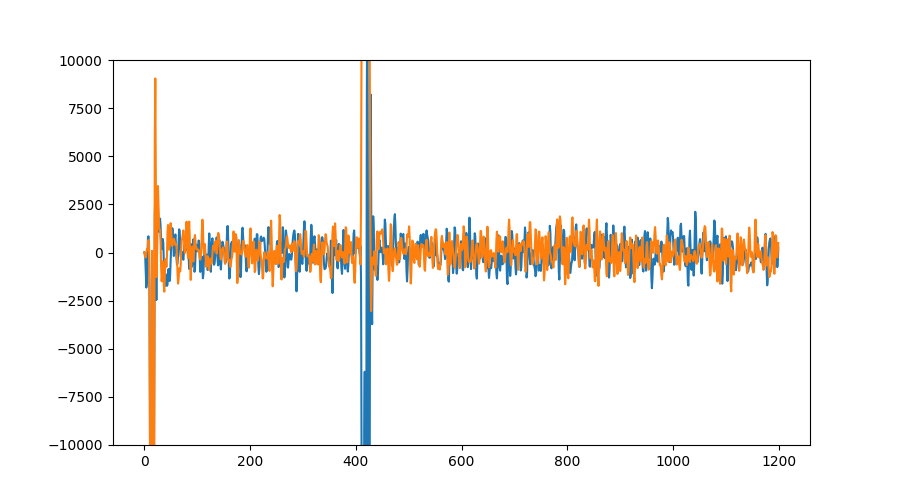

In [174]:
se_fig = plt.figure(figsize=(9,5))
sos = sg.butter(5, 20000,fs=100e3, output='sos')
mrr.amp(10)
mrr.select_well(6)
mrr.freqv
# mrr.run(mrc.build_spinecho(8e-3,75e-6, 150e-6))
# echo_times, echo_amplitudes = mrr.run_cpmg(5, t_echo)
# plt.plot(np.real(sg.sosfilt(sos,mrr.rx_data)))
# plt.plot(np.imag(sg.sosfilt(sos,mrr.rx_data)))
plt.plot(np.real(rxds[4]))
plt.plot(np.imag(rxds[4]))
#Calculate the phase of the first pulse and then correct for it
phase = np.angle(np.mean(mrr.rx_data[10:20]))
# print(phase)

mrr.rx_data = mrr.rx_data * np.exp(-1j*phase) 

# plt.plot(np.real(mrr.rx_data))
# plt.plot(np.imag(mrr.rx_data))
plt.ylim([-10000, 10000])
print(np.mean(np.abs(mrr.rx_data[775:875])))
plt.show()

## Single-Well CPMG

Selecting Well 5
Setting Frequency to 8061236.79389313
Loading Sequence... Done.
Running Sequence
Received Bytes: 1638784

Loading Sequence... Done.
Running Sequence
Received Bytes: 2496



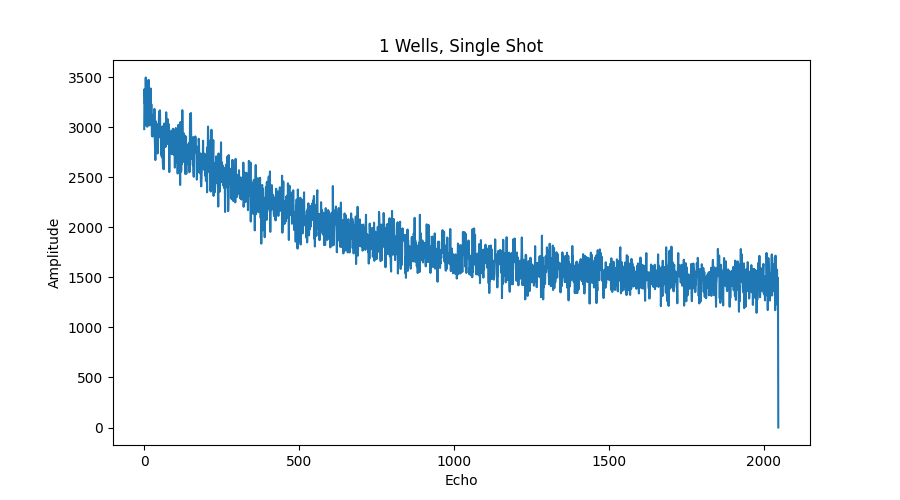

In [187]:
mrr.select_well(5)
t_echo = 2e-3
num_echoes = 2048

mrr.freq(8.062e6-4580+fs[4])

echo_times, echo_amplitudes = mrr.run_cpmg(num_echoes, t_echo, t90=75e-6, t180=150e-6)
time.sleep(0.1)
mrr.run(mrc.build_spinecho(4e-3,500e-6, 500e-6))

cpmg_fig = plt.figure(figsize=(9,5))                                      
# Plot the results
plt.plot(echo_amplitudes)
plt.title("1 Wells, Single Shot")
plt.xlabel("Echo")
plt.ylabel("Amplitude")
# plt.legend(["$T_2$ = %0.2f" % (mrc.get_t2(echo_amplitudes, 3e-3))]) # Put the calculated T2 in the legend
plt.show()     

## Well Tuning Comparison

In [177]:
def calibrate_wells(wells=None, freq=None):
    sos = sg.butter(5, 20000,fs=100e3, output='sos')
    if freq is not None:
        mrr.freq(freq)

    if wells is None:
        wells = np.arange(16) + 1 #Calibrate all wells

    rxds = []
    calfreqs = np.zeros_like(wells, dtype=np.float64)
    for i in range(len(wells)):
        print("Well " + str(i+1))
        mrr.select_well(wells[i])
        mrr.run(mrc.build_spinecho(8e-3,75e-6, 150e-6))
        rxdf = sg.sosfilt(sos,mrr.rx_data)
        time.sleep(1)
        rxds.append(rxdf)
        if(np.mean(np.abs(rxdf[28:58])) < 1200):
            print("empty well?")
            calfreqs[i] = np.nan
        else:
            offset = -get_frequency_offset(rxdf[27:158])
            calfreqs[i] = offset

    return (calfreqs, rxds)

def get_frequency_offset(rxd):
    fs = 100e3
    ft = np.fft.fft(rxd)
    f = np.fft.fftfreq(len(rxd), 1/fs)
    return f[np.argmax(np.abs(ft))]

In [176]:
np.mean(np.abs(rxds[4][1000:1200]))

np.float64(820.1226827593077)

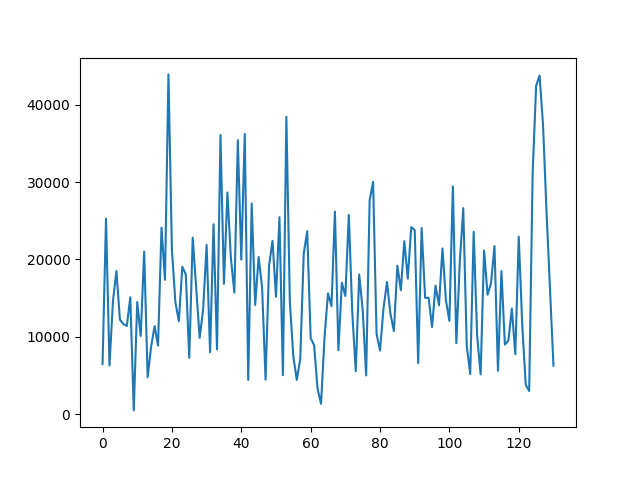

In [171]:
fcfig = plt.figure()
fs = 100e3
ft = np.fft.fft(rxds[4][27:158])
f = np.fft.fftfreq(len(rxds[4][27:158]), 1/fs)
plt.plot(np.abs(ft))
plt.show()

In [180]:
fs

array([  763.35877863, -1526.71755725, -1526.71755725,            nan,
        3816.79389313,    -0.        ,  -763.35877863,            nan,
        5343.51145038,  3053.4351145 ,   763.35877863,  3053.4351145 ,
        5343.51145038,  4580.15267176,            nan,            nan])

In [179]:
fs, rxds = calibrate_wells()

Well 1
Selecting Well 1
Loading Sequence... Done.
Running Sequence
Received Bytes: 4800

Well 2
Selecting Well 2
Loading Sequence... Done.
Running Sequence
Received Bytes: 4800

Well 3
Selecting Well 3
Loading Sequence... Done.
Running Sequence
Received Bytes: 4800

Well 4
Selecting Well 4
Loading Sequence... Done.
Running Sequence
Received Bytes: 4800

empty well?
Well 5
Selecting Well 5
Loading Sequence... Done.
Running Sequence
Received Bytes: 4800

Well 6
Selecting Well 6
Loading Sequence... Done.
Running Sequence
Received Bytes: 4800

Well 7
Selecting Well 7
Loading Sequence... Done.
Running Sequence
Received Bytes: 4800

Well 8
Selecting Well 8
Done.ng Sequence... 
Running Sequence
Received Bytes: 4800

empty well?
Well 9
Selecting Well 9
Done.ng Sequence... 
Running Sequence
Received Bytes: 4800

Well 10
Selecting Well 10
Done.ng Sequence... 
Running Sequence
Received Bytes: 4800

Well 11
Selecting Well 11
Done.ng Sequence... 
Running Sequence
Received Bytes: 4800

Well 12
Selec

In [184]:
import matplotlib.colors
import matplotlib.cm as cm

#Circle Plotting Functions
def plot_well(coords, value, ax=None, cmap_key='viridis'):
    cmap = plt.get_cmap(cmap_key)
    
    if ax is None:
        ax = plt.gca()

    c = plt.Circle(coords, 0.5, color=cmap(value))
    ax.add_patch(c)
    return c

def plot_wellplate(values, ax=None, cmap_key='viridis'):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,3))
        
    #Normalize the axes
    norm = matplotlib.colors.Normalize(vmin=np.nanmin(values), vmax=np.nanmax(values))
    values_normalized = norm(values)
    for i in range(len(values)):
        for j in range(len(values[0])):
            plot_well((i+1,j+1), values_normalized[i,j], ax, cmap_key)
            
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap_key), ax=ax)
            
    ax.set_xlim([0.5,len(values)+0.5])
    ax.set_ylim([0.5,len(values[0])+0.5])

NameError: name 'wellresults' is not defined

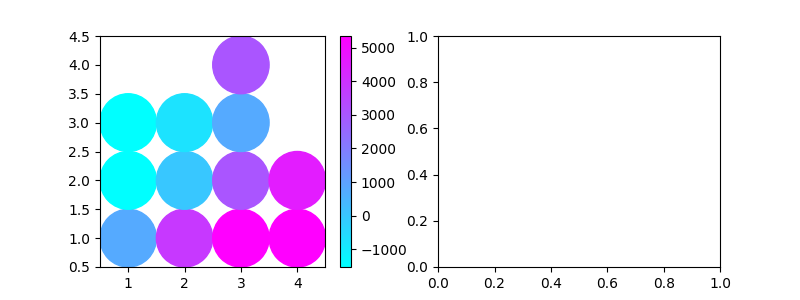

In [186]:
import matplotlib.cm as cm

fig, ax = plt.subplots(1,2,figsize=(8,3))
plot_wellplate(np.reshape(fs, (4, 4)), ax[0], cmap_key='cool')
plot_wellplate(np.reshape(wellresults, (4, 4, -1))[:,:,1], ax[1], cmap_key='Purples')
ax[0].set_title("Field Stength (MHz)")
ax[0].set_xticks(np.arange(1,5))
ax[0].set_yticks(np.arange(1,5))
ax[1].set_title("Signal Amplitude")
ax[1].set_xticks(np.arange(1,5))
ax[1].set_yticks(np.arange(1,5))
plt.show()

In [21]:
wellresults = np.array([
    [8.0565, 3015],
    [8.054, 2387],
    [8.054, 3577],
    [np.nan, 0],
    [8.0578, 2886],
    [8.0565, 2957],
    [8.055, 4121],
    [np.nan, 0],
    [8.06, 2761],
    [8.057, 3438],
    [8.056, 3843],
    [8.059, 2206],
    [8.06, 4578],
    [8.059, 3412],
    [np.nan, 0],
    [np.nan, 0],
])

In [32]:
import numpy as np
import matplotlib.pyplot as plt
fs = 100e3
tx = np.concatenate((np.ones(int(fs*150e-6)), np.zeros(int(fs*10e-3))))

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
C:\Users\hansg\AppData\Local\Temp\ipykernel_56172\2860817139.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.legend(["Well Center Frequencies", "$400 \mu $s Pulse Spectrum"])


<IPython.core.display.Javascript object>


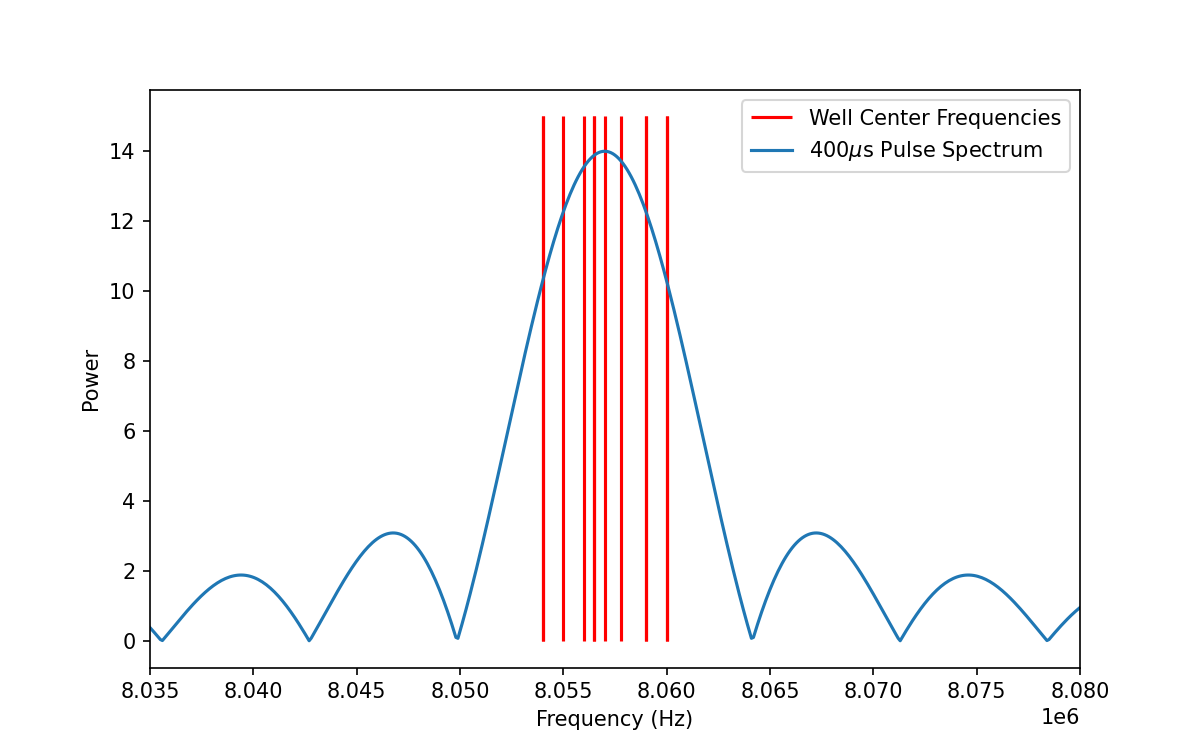

Text(0, 0.5, 'Power')

In [57]:
fig = plt.figure(figsize=(8,5))
freqs = np.fft.fftfreq(len(tx), d=1/fs) + 8.057e6

plt.vlines(wellresults[:,0]*1e6, 0, 15, 'r')
plt.plot(np.fft.fftshift(freqs), np.fft.fftshift(np.abs(np.fft.fft(tx))))

plt.legend(["Well Center Frequencies", "$400 \mu $s Pulse Spectrum"])
plt.xlim([8.035e6,8.08e6])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")

## Multi-Well CPMG

Loading Sequence... Done.
Running Sequence
Received Bytes: 1638784

Loading Sequence... Done.
Running Sequence
Received Bytes: 2496



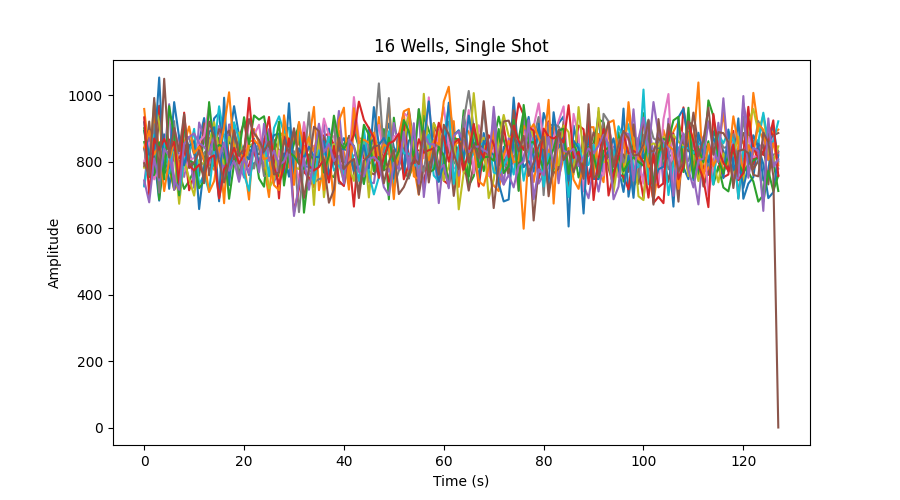

In [52]:
import time 

t_echo = 2e-3
num_echoes = 2048

echo_times, echo_amplitudes = mrr.run_cpmg(num_echoes, t_echo, t90=75e-6, t180=150e-6)
time.sleep(0.1)
mrr.run(mrc.build_spinecho(4e-3,500e-6, 500e-6))

cpmg_fig = plt.figure(figsize=(9,5))                                      
# Plot the results
plt.plot(echo_amplitudes[0::16])
plt.plot(echo_amplitudes[1::16])
plt.plot(echo_amplitudes[2::16])
plt.plot(echo_amplitudes[3::16])
plt.plot(echo_amplitudes[4::16])
plt.plot(echo_amplitudes[5::16])
plt.plot(echo_amplitudes[6::16])
plt.plot(echo_amplitudes[7::16])
plt.plot(echo_amplitudes[8::16])
plt.plot(echo_amplitudes[9::16])
plt.plot(echo_amplitudes[10::16])
plt.plot(echo_amplitudes[11::16])
plt.plot(echo_amplitudes[12::16])
plt.plot(echo_amplitudes[13::16])
plt.plot(echo_amplitudes[14::16])
plt.plot(echo_amplitudes[15::16])
plt.title("16 Wells, Single Shot")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
# plt.legend(["$T_2$ = %0.2f" % (mrc.get_t2(echo_amplitudes, 3e-3))]) # Put the calculated T2 in the legend
plt.show()     

## Run an IR CPMG Experiment

Loading Sequence... Done.
Running Sequence
Received Bytes: 1201024



<IPython.core.display.Javascript object>


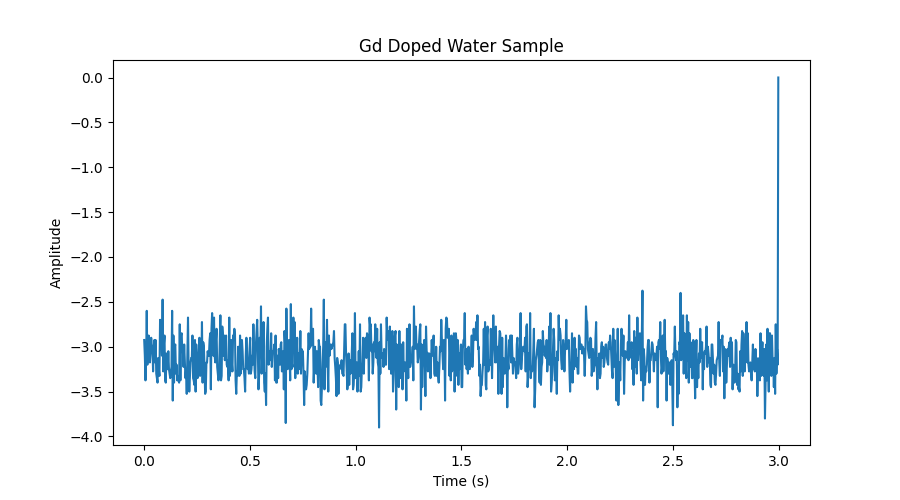

In [268]:
t_echo = 3e-3
num_echoes = 1000
inversion_time = 1e-3

echo_times, echo_amplitudes = mrr.run_ir(inversion_time, num_echoes, t_echo)

cpmg_fig = plt.figure(figsize=(9,5))                                      # Plot the results
plt.plot(echo_times, echo_amplitudes)
plt.title("Gd Doped Water Sample")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
# plt.legend(["$T_2$ = %0.2f" % (mrc.get_t2(echo_amplitudes, 3e-3))]) # Put the calculated T2 in the legend
plt.show()  

## Run an IR T1 Experiment

Loading Sequence... Done.
Running Sequence
Received Bytes: 1201024

Loading Sequence... Done.
Running Sequence
Received Bytes: 1250944

Loading Sequence... Done.
Running Sequence
Received Bytes: 1300864

Loading Sequence... Done.
Running Sequence
Received Bytes: 1350720

Loading Sequence... Done.
Running Sequence
Received Bytes: 1400640



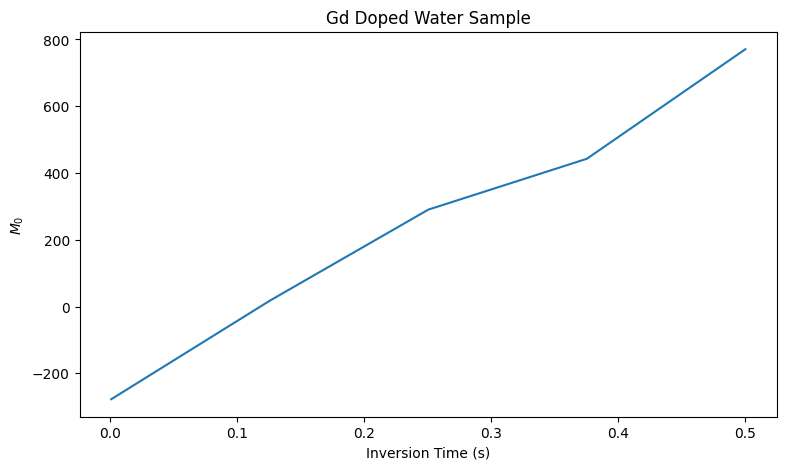

In [19]:
t_echo = 3e-3
num_echoes = 1000
inversion_times = np.linspace(1e-3, 0.5, 5)

initial_magnetizations = mrr.run_ir_t1(inversion_times, num_echoes, t_echo)

cpmg_fig = plt.figure(figsize=(9,5))                                      # Plot the results
plt.plot(inversion_times, initial_magnetizations[5:])
plt.title("Gd Doped Water Sample")
plt.xlabel("Inversion Time (s)")
plt.ylabel("$M_0$")
# plt.legend(["$T_1$ = %0.2f" % (mrc.get_t2(echo_amplitudes, 3e-3))]) # Put the calculated T2 in the legend
plt.show()   